In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, root_mean_squared_error

In [111]:
df = pd.read_csv('../data/Data_Indekos_Jabodetabek_Mamikos.csv')
df.head()

,room_name,owner_name,region,location,room_size,is_electricity_included,price_before_discount_bs,all_facilities_bs,room_availability_bs,deposit_amount_bs,price,rating,rating_count,transaction_count,tipe_kos,discount_amount,url
0,Kost 0088 Tipe A Babakan Madang Bogor,Yan,Bogor,Babakan Madang,3 x 4 meter,Termasuk listrik (implied),NaN,3 x 4 meter; Termasuk listrik; Kasur; Bantal; ...,NaN,Rp100.000/3 hari,Rp950.000,Not found,Not found,Not found,Kos Campur,Not found,https://mamikos.com/room/kost-kabupaten-bogor-...
1,Kost 121 Cinere Depok,Agustin,Depok,Cinere,4 x 3 meter,Tidak termasuk listrik,NaN,4 x 3 meter; Tidak termasuk listrik; AC; Kasur...,Kamar penuh,NaN,Rp1.100.000,Not found,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-depok-kost-...
2,Kost 126 Pondok Aren Tangerang Selatan,Hanny,Tangerang Selatan,Kecamatan Pondok Aren,3 x 3 meter,Tidak termasuk listrik,NaN,3 x 3 meter; Tidak termasuk listrik; AC; Kasur...,Tersisa1 kamar,NaN,Rp1.100.000,Not found,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-tangerang-s...
3,Kost 20088 Babakan Madang Bogor,Yan,Bogor,Babakan Madang,3 x 4 meter,Termasuk listrik (implied),NaN,3 x 4 meter; Termasuk listrik; Kasur; Lemari B...,Tersisa2 kamar,NaN,Rp700.000,Not found,Not found,Not found,Kos Campur,Not found,https://mamikos.com/room/kost-kabupaten-bogor-...
4,Kost 21 Alam Sutera Tipe A Serpong Utara Tange...,Juliandy,Tangerang Selatan,Kecamatan Serpong Utara,2 x 3 meter,Termasuk listrik (implied),NaN,2 x 3 meter; Termasuk listrik; AC; Kasur; Lema...,Tersisa2 kamar,Rp500.000,Rp1.500.000,1.0,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-tangerang-s...


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2485 entries, 0 to 2484
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   room_name                 2485 non-null   object
 1   owner_name                2485 non-null   object
 2   region                    2485 non-null   object
 3   location                  2485 non-null   object
 4   room_size                 2459 non-null   object
 5   is_electricity_included   2462 non-null   object
 6   price_before_discount_bs  641 non-null    object
 7   all_facilities_bs         2464 non-null   object
 8   room_availability_bs      2049 non-null   object
 9   deposit_amount_bs         1690 non-null   object
 10  price                     2485 non-null   object
 11  rating                    2485 non-null   object
 12  rating_count              2485 non-null   object
 13  transaction_count         2485 non-null   object
 14  tipe_kos                

In [113]:
df.describe()

,room_name,owner_name,region,location,room_size,is_electricity_included,price_before_discount_bs,all_facilities_bs,room_availability_bs,deposit_amount_bs,price,rating,rating_count,transaction_count,tipe_kos,discount_amount,url
count,2485,2485,2485,2485,2459,2462,641,2464,2049,1690,2485,2485,2485,2485,2485,2485,2485
unique,2311,948,10,207,355,2,163,2258,6,77,489,27,79,124,3,157,2311
top,Kost Ruma Cemara CH4 Meadow Green C Cikarang S...,Kos dikelola oleh Dida,Bekasi,Cikarang Selatan,3 x 3 meter,Tidak termasuk listrik,Rp1.825.000,3.5 x 5 meter; Tidak termasuk listrik; AC; Kas...,Tersisa1 kamar,Rp300.000,Rp1.500.000,Not found,Not found,Not found,Kos Campur,Not found,https://mamikos.com/room/kost-kabupaten-bekasi...
freq,10,414,315,131,571,1928,36,8,616,460,113,733,1362,923,1409,1347,10


In [114]:
df.isna().sum()

room_name                      0
owner_name                     0
region                         0
location                       0
room_size                     26
is_electricity_included       23
price_before_discount_bs    1844
all_facilities_bs             21
room_availability_bs         436
deposit_amount_bs            795
price                          0
rating                         0
rating_count                   0
transaction_count              0
tipe_kos                       0
discount_amount                0
url                            0
dtype: int64

## Data Cleaning

### ekstrak wilayah jakarta saja

karena pada aplikasi ini hanya akan berfokus pada wilayah jakarta maka kita ambil wilayah jakarta saja

In [115]:
df = df[(df['region'] == 'Jakarta Utara') | (df['region'] == 'Jakarta Barat') | (df['region'] == 'Jakarta Pusat') | (df['region'] == 'Jakarta Selatan') | (df['region'] == 'Jakarta Timur')]
df.head()

,room_name,owner_name,region,location,room_size,is_electricity_included,price_before_discount_bs,all_facilities_bs,room_availability_bs,deposit_amount_bs,price,rating,rating_count,transaction_count,tipe_kos,discount_amount,url
7,Kost 2nd Home Tipe Executive Palmerah Jakarta ...,Henry Tirtasaputra Junior,Jakarta Barat,Palmerah,4 x 3 meter,Tidak termasuk listrik,NaN,4 x 3 meter; Tidak termasuk listrik; AC; Kasur...,Tersisa1 kamar,Rp1.000.000,Rp3.100.000,5.0,Not found,Not found,Kos Campur,Diskon 256rb,https://mamikos.com/room/kost-kota-jakarta-bar...
8,Kost 38 Lt3 Tanjung Priok Jakarta Utara,Hadi winata,Jakarta Utara,Tanjung Priok,3 x 3 meter,Termasuk listrik (implied),NaN,3 x 3 meter; Termasuk listrik; Kasur; Meja; Ku...,NaN,Rp10.000/2 hari,Rp700.000,4.1,Not found,Not found,Kos Putra,Not found,https://mamikos.com/room/kost-kota-jakarta-uta...
9,Kost 3tranches Home SCBD Tipe A Kebayoran Baru...,Threetranches Manajemen,Jakarta Selatan,Kebayoran Baru,3 x 5 meter,Tidak termasuk listrik,NaN,3 x 5 meter; Tidak termasuk listrik; AC; Kasur...,NaN,Rp1.000.000,Rp3.500.000,4.0,(5),22 transaksi berhasil di kos ini,Kos Campur,Not found,https://mamikos.com/room/kost-kota-jakarta-sel...
10,Kost 3tranches Home Senopati Kebayoran Baru Ja...,Threetranches Manajemen,Jakarta Selatan,Kebayoran Baru,4 x 4 meter,Tidak termasuk listrik,NaN,4 x 4 meter; Tidak termasuk listrik; AC; Kasur...,NaN,Rp1.000.000,Rp3.800.000,4.6,Not found,13 transaksi berhasil di kos ini,Kos Campur,Diskon 304rb,https://mamikos.com/room/kost-kota-jakarta-sel...
11,Kost 3tranches Home Tipe D Cilandak Jakarta Se...,Threetranches Manajemen,Jakarta Selatan,Cilandak,4.6 x 6 meter,Tidak termasuk listrik,NaN,4.6 x 6 meter; Tidak termasuk listrik; AC; Kas...,NaN,NaN,Rp4.000.000,3.6,(1),12 transaksi berhasil di kos ini,Kos Campur,Diskon 193rb,https://mamikos.com/room/kost-kota-jakarta-sel...


In [116]:
for col in df.columns:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'room_name': ['Kost 2nd Home Tipe Executive Palmerah Jakarta Barat'
 'Kost 38 Lt3 Tanjung Priok Jakarta Utara'
 'Kost 3tranches Home SCBD Tipe A Kebayoran Baru Jakarta Selatan' ...
 'Kost Yudi Residence Tipe C Tanjung Priok Jakarta Utara'
 'Kost Yume Home Executive Kali Deres Jakarta Barat'
 'Rumah Kontrakan Komplek Sunter Jaya Baru Tanjung Priok Jakarta Utara']
Unique values in 'owner_name': ['Henry Tirtasaputra Junior' 'Hadi winata' 'Threetranches Manajemen'
 'Naimi Gandaria Simanjuntak' 'ibu arif' 'Alya' 'IIN KOST PUTRI'
 'Pemilik Kos' 'ibu akim' 'Oki Inderawan' 'Fifik Asfiati R'
 'Almic Guesthouse Jakarta' 'Admin Almic kost' 'Amriyani'
 'Paulina Pangabean' 'Ratna Kusuma Dewi' 'Aisyatul umro'
 'Kos dikelola oleh Dida' 'Kos dikelola oleh Bella'
 'Kos dikelola oleh Maya' 'Eva' 'Andrias Suganda' 'Angela Catharina'
 'Dini Hilyah' 'meila sutanti' 'Ivana' 'William Iskandar' 'nanda soraya'
 'yuli' 'Debby Febrian' 'Yuferdi' 'Irwin' 'Emiliana Riyadi Eti' 'Melita'
 'Koster Co

### cleaning price

In [117]:
# ekstrak harga dari string menjadi float dan hapus rp dan titik
df['price'] = df['price'].str.replace('Rp', '').str.replace('.', '').astype(float)

In [118]:
# ekstrak harga diskon dari string menjadi float, ganti 'Not found' dengan 0, dan hapus rp dan titik
df['discount_amount'] = df['discount_amount'].replace('Not found', 0)
df['discount_amount'] = df['discount_amount'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0) * 1000

In [119]:
# impute harga sebelum diskon dengan menjumlahkan harga setelah diskon dengan jumlah diskon
df['price_before_discount_bs'] = df['price'] + df['discount_amount']

### clean rating

In [120]:
df['rating'] = df['rating'].replace('Not found', 0).astype(float).fillna(0)
df['rating_count'] = df['rating_count'].replace('Not found', 0)
df['rating_count'] = df['rating_count'].astype(str).str.replace(r'[()]', '', regex=True).astype(float).fillna(0)
df.loc[df['rating_count'] == 0, 'rating'] = 0

### clean transaction count

In [121]:
df['transaction_count'] = df['transaction_count'].replace('Not found', 0)
df['transaction_count'] = df['transaction_count'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0)

### clean luas kamar

In [122]:
# ambil hanya angka dari room_size, ekstrak panjang dan lebar, lalu hitung luas kamar
df[['length', 'width']] = df['room_size'].astype(str).str.extract(r'([\d\.]+)\s*x\s*([\d\.]+)').astype(float)
df['room_area'] = df['length'] * df['width']

In [123]:
# impute room_area dengan modus karena banyak nilai yang hilang dan tidak bisa dihitung dari length dan width
df['room_area'] = df['room_area'].fillna(df['room_area'].mode()[0], inplace=False)

In [124]:
# bulatkan room_area ke 2 desimal
df['room_area'].round(2)

7       12.0
8        9.0
9       15.0
10      16.0
11      27.6
        ... 
2456     9.0
2457     9.0
2458     9.0
2459    12.0
2481    12.0
Name: room_area, Length: 1233, dtype: float64

### clean ketersediaan kamar

In [125]:
# ubah ketersediaan kamar menjadi angka
df['room_availability_bs']=df['room_availability_bs'].map({'Tersisa1 kamar': 1,
    'Tersisa2 kamar': 2,
    'Kamar penuh,lihat kos lainnya': 0,
    'Kamar penuh,lihat tipe kamar lainnya': 0,
    'Tersisa3 kamar': 3
}).fillna(0)

### clean location (kecamatan)

In [126]:
# hapus kata kecamatan dalam kolom location, lalu strip spasi dan ubah ke title case
df['location'] = (
    df['location']
    .str.replace(r'(?i)^\s*kecamatan\s*', '', regex=True)
    .str.strip()
    .str.title()
)

### map is_discount

In [127]:
df['is_discount'] = df.apply(
    lambda row: 1 if row['discount_amount'] > 0 else 0, 
    axis=1
)

### Facilities

- jika kost mempunyai fasilitas tersebut -> 1
- jika kost tidak mempunyai fasilitas tersebut -> 0

In [128]:
df['all_facilities_bs'] = df['all_facilities_bs'].str.strip().fillna('')

teks_listrik_bersih = df['is_electricity_included'].fillna('').astype(str).str.strip().str.lower()
df['is_electricity'] = teks_listrik_bersih.apply(
    lambda x: 1 if 'termasuk listrik' in x and 'tidak' not in x else 0
)

def check_fac(text, keywords):
    return 1 if any(word in text for word in keywords) else 0

print("Mengelompokkan fasilitas serupa...")

df['is_kamar_mandi_dalam'] = df['all_facilities_bs'].apply(lambda x: 1 if 'K. Mandi Dalam' in x else 0)
df['is_kloset_duduk'] = df['all_facilities_bs'].apply(lambda x: 1 if 'Kloset Duduk' in x else 0)

df['fac_keamanan'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['CCTV', 'Penjaga Kos', 'Pengurus Kos']))

df['fac_sirkulasi_udara'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['Jendela', 'Ventilasi']))

df['fac_parkir_motor'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['Parkir Motor', 'Parkir Sepeda', 'Parkir Motor & Sepeda']))
df['fac_parkir_mobil'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['Parkir Mobil']))

df['fac_ruang_bersama'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['R. Tamu', 'R. Makan', 'R. Santai', 'Rooftop', 'Balcon', 'Taman']))

df['fac_layanan_kebersihan'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['Laundry', 'Mesin Cuci', 'Cleaning service', 'R. Cuci']))
df['fac_area_jemur'] = df['all_facilities_bs'].apply(lambda x: check_fac(x, ['R. Jemur', 'Jemuran']))

df['is_full_furnished'] = df['all_facilities_bs'].apply(
    lambda x: 1 if all(word in x for word in ['Kasur', 'Lemari Baju', 'Meja']) else 0
)

keywords_to_skip = [
    'meter', 'listrik', 'K. Mandi', 'Parkir', 'R. ', 'Jemur', 'Laundry', 'Cleaning', 
    'Kasur', 'Lemari', 'Meja', 'CCTV', 'Penjaga', 'Pengurus', 'Jendela', 'Ventilasi', 'Kloset', 'Taman', 'Rooftop', 'Balcon', 'R. Tamu', 'R. Makan', 'R. Santai',
]

all_facilities_list = []
for x in df['all_facilities_bs'].str.split(';'):
    for item in x:
        item = item.strip()
        if item and not any(skip in item for skip in keywords_to_skip):
            all_facilities_list.append(item)

fac_counts = Counter(all_facilities_list)
pop_facs = [f for f, c in fac_counts.items() if c > 50]

list_kolom_fac_tambahan = []
for fac in pop_facs:
    nama_kolom = f"fac_{fac.lower().replace(' ', '_').replace('.', '').replace('&', 'and')}"
    list_kolom_fac_tambahan.append(nama_kolom)
    df[nama_kolom] = df['all_facilities_bs'].apply(
        lambda x: 1 if fac in [i.strip() for i in x.split(';')] else 0
    )

fitur_grouping = [
    'is_kloset_duduk', 'fac_keamanan', 'fac_sirkulasi_udara', 
    'fac_parkir_motor', 'fac_parkir_mobil', 'fac_ruang_bersama', 
    'fac_layanan_kebersihan', 'fac_area_jemur', 'is_full_furnished'
]

features_to_use = [
    'room_area', 'is_electricity', 'is_kamar_mandi_dalam', 'is_discount', 
    'region', 'tipe_kos'
] + fitur_grouping + list_kolom_fac_tambahan

print(f"\nTotal Fitur yang digunakan: {len(features_to_use)}")
print(f"Daftar Fitur: {features_to_use}")

Mengelompokkan fasilitas serupa...

Total Fitur yang digunakan: 32
Daftar Fitur: ['room_area', 'is_electricity', 'is_kamar_mandi_dalam', 'is_discount', 'region', 'tipe_kos', 'is_kloset_duduk', 'fac_keamanan', 'fac_sirkulasi_udara', 'fac_parkir_motor', 'fac_parkir_mobil', 'fac_ruang_bersama', 'fac_layanan_kebersihan', 'fac_area_jemur', 'is_full_furnished', 'fac_ac', 'fac_tv', 'fac_bantal', 'fac_cermin', 'fac_shower', 'fac_air_panas', 'fac_wifi', 'fac_kulkas', 'fac_dapur', 'fac_dispenser', 'fac_kipas_angin', 'fac_kursi', 'fac_guling', 'fac_wastafel', 'fac_ember_mandi', 'fac_mesin_cuci', 'fac_bak_mandi']


## Visualization

### Harga rata-rata kos sesuai tipe (campur,putra, putri)

In [129]:
df_grouped = df.groupby('tipe_kos')['price'].agg(
    Rata_Rata='mean',
    Median='median',
    Jumlah_Kos='count'
).reset_index()

In [130]:
df_grouped['Rata_Rata'] = df_grouped['Rata_Rata'].round(2)
print("--- Tabel Analisis Harga Berdasarkan Tipe Kos (Jakarta) ---")
print(df_grouped)

--- Tabel Analisis Harga Berdasarkan Tipe Kos (Jakarta) ---
     tipe_kos   Rata_Rata     Median  Jumlah_Kos
0  Kos Campur  2029651.65  1865000.0         785
1   Kos Putra  1436244.52  1282500.0          93
2   Kos Putri  1800883.94  1727000.0         355


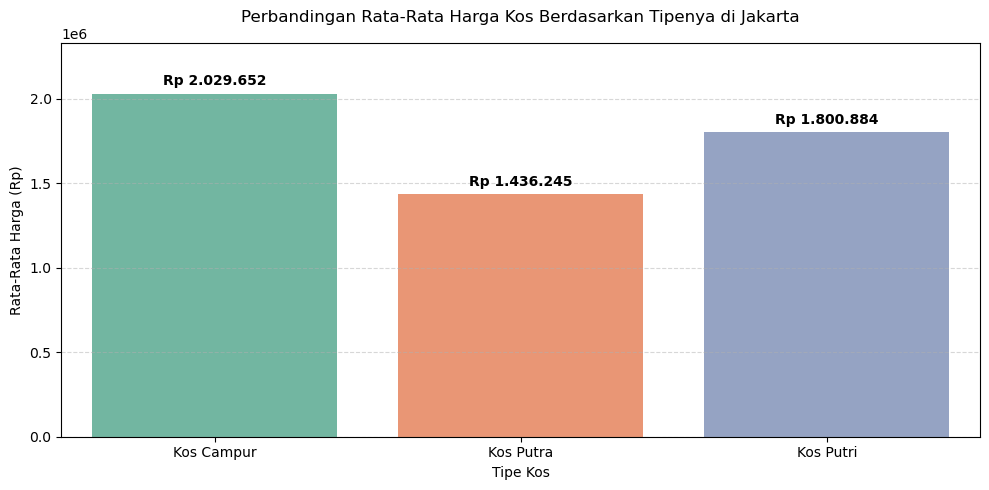

In [131]:
# visualisasi perbandingan rata-rata harga kos berdasarkan tipe kos di Jakarta
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_grouped, 
    x='tipe_kos', 
    y='Rata_Rata', 
    palette='Set2', 
    hue='tipe_kos', 
    legend=False
)

for index, row in df_grouped.iterrows():
    plt.text(
        x=index, 
        y=row['Rata_Rata'] + 30000, 
        s=f"Rp {row['Rata_Rata']:,.0f}".replace(",", "."), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold'
    )

plt.title('Perbandingan Rata-Rata Harga Kos Berdasarkan Tipenya di Jakarta', fontsize=12, pad=15)
plt.xlabel('Tipe Kos', fontsize=10)
plt.ylabel('Rata-Rata Harga (Rp)', fontsize=10)
plt.ylim(0, max(df_grouped['Rata_Rata']) + 300000) # Memberi ruang untuk label teks
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Kesimpulan : harga yang paling mahal kos campur -> kos perempuan -> kos laki2

### Harga rata-rata kos dari region Jakarta (Pusat, Barat, Timur, Utara, Selatan)

In [132]:
df_grouped = df.groupby('region')['price'].agg(
    Rata_Rata='mean',
    Median='median',
    Jumlah_Kos='count'
).reset_index()

In [133]:
df_grouped['Rata_Rata'] = df_grouped['Rata_Rata'].round(2)
print("--- Tabel Analisis Harga Berdasarkan wilayahnya (Jakarta) ---")
print(df_grouped)

--- Tabel Analisis Harga Berdasarkan wilayahnya (Jakarta) ---
            region   Rata_Rata     Median  Jumlah_Kos
0    Jakarta Barat  2041154.97  1957000.0         231
1    Jakarta Pusat  2054337.77  1850000.0         229
2  Jakarta Selatan  2337112.03  2210000.0         241
3    Jakarta Timur  1549845.44  1497250.0         298
4    Jakarta Utara  1705611.10  1612500.0         234


jaksel -> jakpus -> jakbar -> jakut -> jaktim

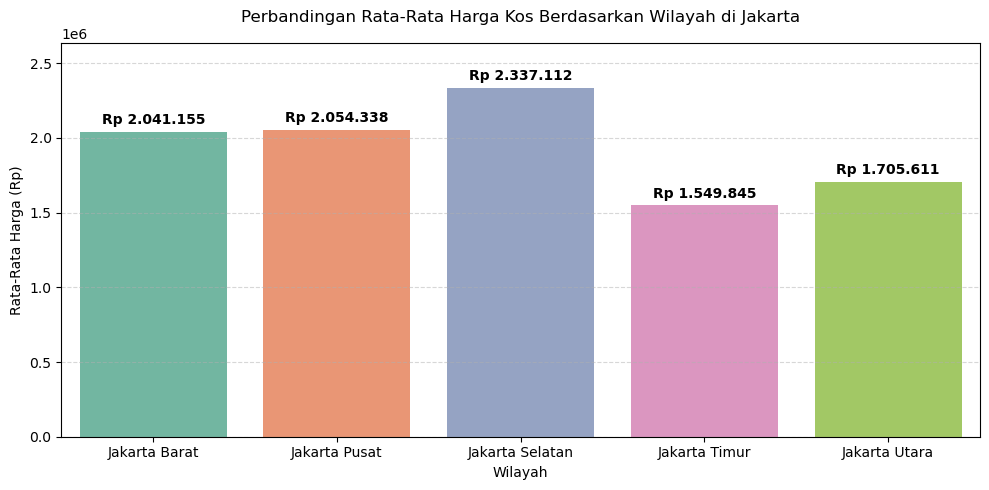

In [134]:
# visualisasi perbandingan rata-rata harga kos berdasarkan wilayah di Jakarta

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_grouped, 
    x='region', 
    y='Rata_Rata', 
    palette='Set2', 
    hue='region', 
    legend=False
)

for index, row in df_grouped.iterrows():
    plt.text(
        x=index, 
        y=row['Rata_Rata'] + 30000, 
        s=f"Rp {row['Rata_Rata']:,.0f}".replace(",", "."), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold'
    )

plt.title('Perbandingan Rata-Rata Harga Kos Berdasarkan Wilayah di Jakarta', fontsize=12, pad=15)
plt.xlabel('Wilayah', fontsize=10)
plt.ylabel('Rata-Rata Harga (Rp)', fontsize=10)
plt.ylim(0, max(df_grouped['Rata_Rata']) + 300000) # Memberi ruang untuk label teks
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Harga rata-rata kos berdasarkan luas ruangan

In [135]:
def kategorikan_luas(area):
    if area < 10:
        return 'Kecil (<10m²)'
    elif area < 20:
        return 'Sedang (10-20m²)'
    else:
        return 'Besar (>20m²)'

In [136]:
df_area = df.copy()

In [137]:
df_area['kategori_luas'] = df_area['room_area'].apply(kategorikan_luas)

In [138]:
df_area_stats = df_area.groupby('kategori_luas', observed=True)['price'].agg(
    Rata_Rata='mean',
    Median='median',
    Jumlah_Kos='count'
).reset_index()

df_area_stats['Rata_Rata'] = df_area_stats['Rata_Rata'].round(2)
df_area_stats['Median'] = df_area_stats['Median'].round(2)

print("--- Tabel Analisis Harga Berdasarkan Kategori Luas Kamar (Jakarta) ---")
print(df_area_stats)

--- Tabel Analisis Harga Berdasarkan Kategori Luas Kamar (Jakarta) ---
      kategori_luas   Rata_Rata     Median  Jumlah_Kos
0     Besar (>20m²)  2854640.62  2952500.0          64
1     Kecil (<10m²)  1597389.83  1573500.0         596
2  Sedang (10-20m²)  2149074.60  2025000.0         573


In [139]:
df_area_grouped = df_area.groupby('kategori_luas', observed=True)['price'].mean().reset_index()
order = ['Kecil (<10m²)', 'Sedang (10-20m²)', 'Besar (>20m²)']
df_area_grouped['kategori_luas'] = pd.Categorical(df_area_grouped['kategori_luas'], categories=order, ordered=True)
df_area_grouped = df_area_grouped.sort_values('kategori_luas')

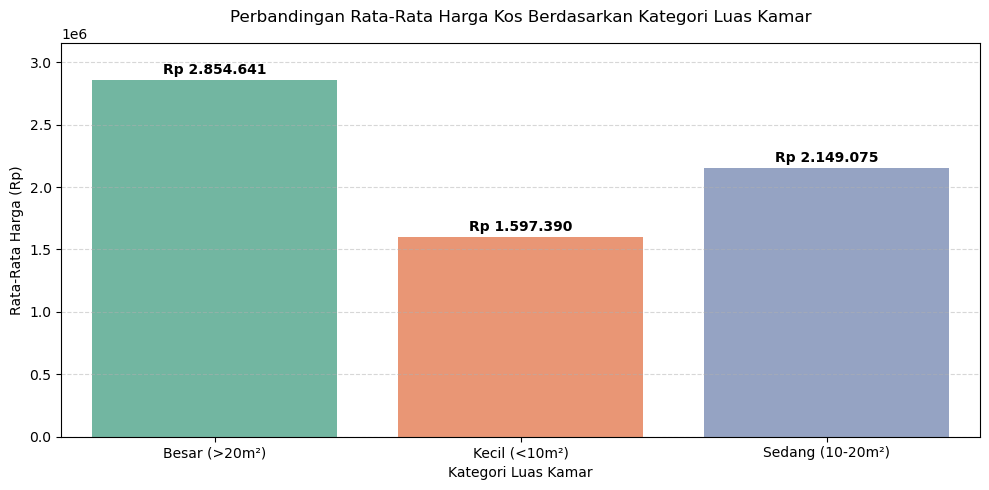

In [140]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_area_stats, 
    x='kategori_luas', 
    y='Rata_Rata', 
    palette='Set2', 
    hue='kategori_luas', 
    legend=False
)

for index, row in df_area_stats.iterrows():
    harga = row['Rata_Rata']
    plt.text(
        x=index, 
        y=harga + 30000, 
        s=f"Rp {harga:,.0f}".replace(",", "."), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold'
    )

plt.title('Perbandingan Rata-Rata Harga Kos Berdasarkan Kategori Luas Kamar', fontsize=12, pad=15)
plt.xlabel('Kategori Luas Kamar', fontsize=10)
plt.ylabel('Rata-Rata Harga (Rp)', fontsize=10)
plt.ylim(0, df_area_stats['Rata_Rata'].max() + 300000) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Heatmap korelasi antar variabel dengan Harga (Price)

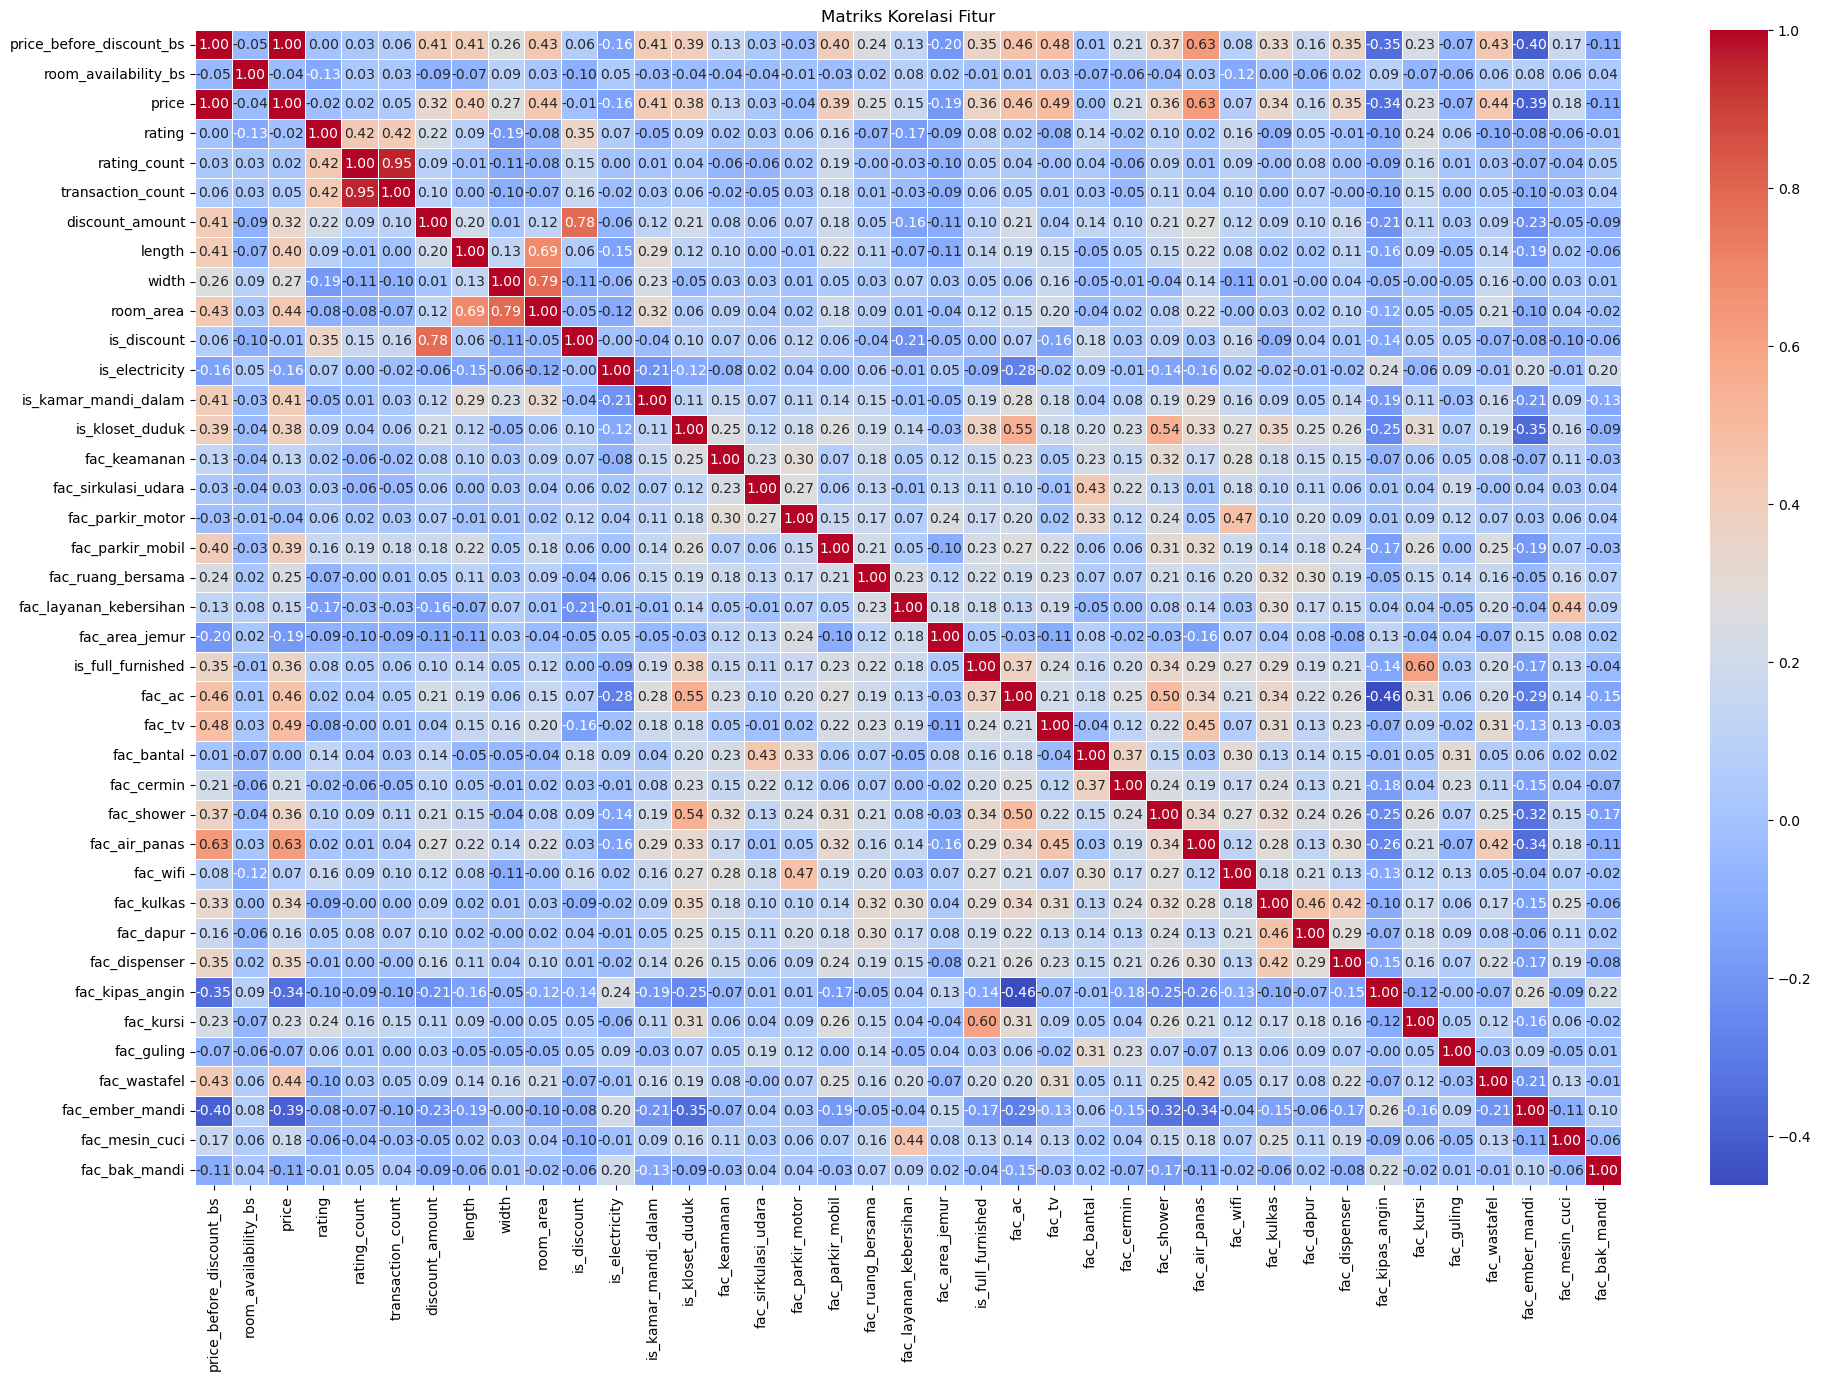

In [141]:
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(23, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur')
plt.show()

## Modelling

### drop kolom yang tidak dipakai

In [142]:
df = df.drop(columns=['length', 'width', 'room_size', 'is_electricity_included', 'url', 'owner_name','deposit_amount_bs', 'all_facilities_bs', 'discount_amount', 'price_before_discount_bs'])

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1233 entries, 7 to 2481
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   room_name               1233 non-null   object 
 1   region                  1233 non-null   object 
 2   location                1233 non-null   object 
 3   room_availability_bs    1233 non-null   float64
 4   price                   1233 non-null   float64
 5   rating                  1233 non-null   float64
 6   rating_count            1233 non-null   float64
 7   transaction_count       1233 non-null   float64
 8   tipe_kos                1233 non-null   object 
 9   room_area               1233 non-null   float64
 10  is_discount             1233 non-null   int64  
 11  is_electricity          1233 non-null   int64  
 12  is_kamar_mandi_dalam    1233 non-null   int64  
 13  is_kloset_duduk         1233 non-null   int64  
 14  fac_keamanan            1233 non-null   int64

### Export csv berisi data yang sudah diclean

In [144]:
df.to_csv('../data/Data_Indekos_Jabodetabek_Mamikos_Cleaned.csv', index=False, float_format='%.2f')

### Model Linear Regression (baseline)

In [145]:
X = df.drop(columns=['price', 'location','room_name'])
y = df['price']

X = pd.get_dummies(X, columns=['region', 'tipe_kos'], drop_first=True)
X = X.astype(float) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("HASIL EVALUASI MODEL PIPELINE AKHIR (Linear Regression)")
print(f"R2 Score (Pada Skala Logarithm) : {r2:.4f}")
print(f"Mean Absolute Error (Rupiah)    : Rp {mae:,.0f}".replace(",", "."))
print(f"Mean Squared Error (Rupiah)     : Rp {mse:,.0f}".replace(",", "."))
print(f"Root Mean Squared Error (Rupiah): Rp {rmse:,.0f}".replace(",", "."))


HASIL EVALUASI MODEL PIPELINE AKHIR (Linear Regression)
R2 Score (Pada Skala Logarithm) : 0.7085
Mean Absolute Error (Rupiah)    : Rp 294.007
Mean Squared Error (Rupiah)     : Rp 175.013.337.810
Root Mean Squared Error (Rupiah): Rp 418.346


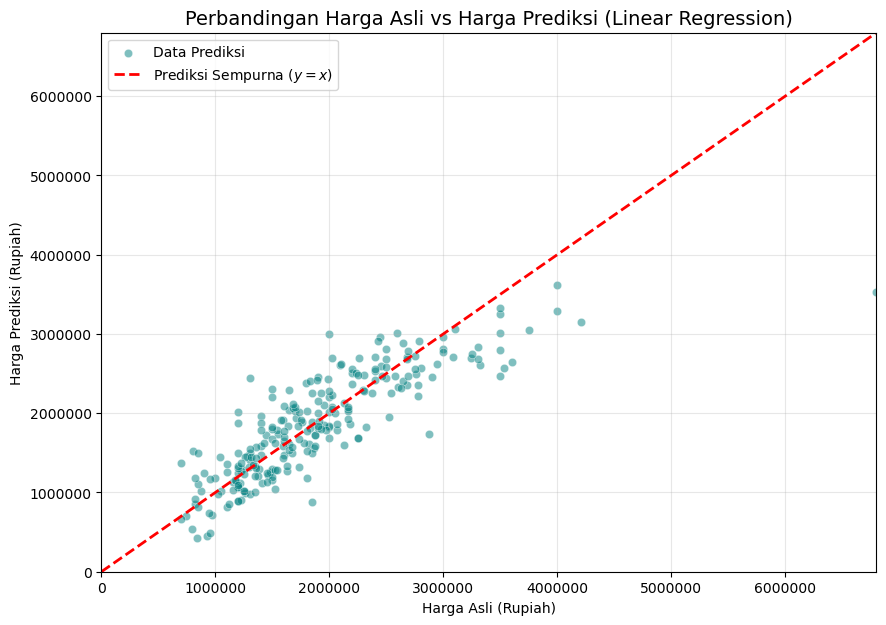

In [146]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal', label='Data Prediksi')

max_val = int(max(y_test.max(), y_pred.max()))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Prediksi Sempurna ($y=x$)')

plt.title('Perbandingan Harga Asli vs Harga Prediksi (Linear Regression)', fontsize=14)
plt.xlabel('Harga Asli (Rupiah)')
plt.ylabel('Harga Prediksi (Rupiah)')

plt.ticklabel_format(style='plain', axis='both')
plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Model Random Forest (tanpa log transformation)

In [147]:
X = df.drop(columns=['price', 'location','room_name'])
y = df['price']

X = pd.get_dummies(X, columns=['region', 'tipe_kos'], drop_first=True)
X = X.astype(float) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("HASIL EVALUASI MODEL PIPELINE AKHIR (Random Forest Regressor)")
print(f"R2 Score (Pada Skala Logarithm) : {r2:.4f}")
print(f"Mean Absolute Error (Rupiah)    : Rp {mae:,.0f}".replace(",", "."))
print(f"Mean Squared Error (Rupiah)     : Rp {mse:,.0f}".replace(",", "."))
print(f"Root Mean Squared Error (Rupiah): Rp {rmse:,.0f}".replace(",", "."))


HASIL EVALUASI MODEL PIPELINE AKHIR (Random Forest Regressor)
R2 Score (Pada Skala Logarithm) : 0.7525
Mean Absolute Error (Rupiah)    : Rp 245.146
Mean Squared Error (Rupiah)     : Rp 148.636.146.207
Root Mean Squared Error (Rupiah): Rp 385.534


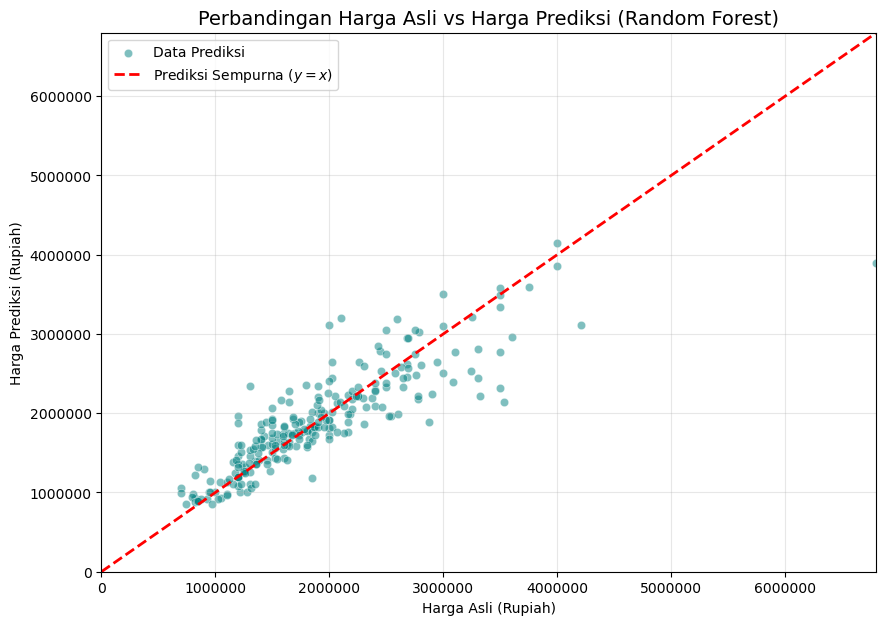

In [148]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal', label='Data Prediksi')

max_val = int(max(y_test.max(), y_pred.max()))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Prediksi Sempurna ($y=x$)')

plt.title('Perbandingan Harga Asli vs Harga Prediksi (Random Forest)', fontsize=14)
plt.xlabel('Harga Asli (Rupiah)')
plt.ylabel('Harga Prediksi (Rupiah)')

plt.ticklabel_format(style='plain', axis='both')
plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Model Random Forest (with log transformation)
pakai yang log agar lebih bisa mengatasi data yang skewed

In [149]:
X = df.drop(columns=['price', 'location', 'room_name'])
y = np.log1p(df['price']) 

X = pd.get_dummies(X, columns=['region', 'tipe_kos'], drop_first=True)
X = X.astype(float) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_log_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_log_model.fit(X_train, y_train)

y_pred_log = rf_log_model.predict(X_test)

r2 = r2_score(y_test, y_pred_log)

y_test_original = np.expm1(y_test)
y_pred_original = np.expm1(y_pred_log)
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = root_mean_squared_error(y_test_original, y_pred_original)

print("HASIL EVALUASI MODEL PIPELINE AKHIR (Random Forest Regressor dengan Log)")
print(f"R2 Score (Pada Skala Logarithm) : {r2:.4f}")
print(f"Mean Absolute Error (Rupiah)    : Rp {mae:,.0f}".replace(",", "."))
print(f"Mean Squared Error (Rupiah)     : Rp {mse:,.0f}".replace(",", "."))
print(f"Root Mean Squared Error (Rupiah): Rp {rmse:,.0f}".replace(",", "."))

HASIL EVALUASI MODEL PIPELINE AKHIR (Random Forest Regressor dengan Log)
R2 Score (Pada Skala Logarithm) : 0.8105
Mean Absolute Error (Rupiah)    : Rp 240.958
Mean Squared Error (Rupiah)     : Rp 148.889.345.611
Root Mean Squared Error (Rupiah): Rp 385.862


### Cek latensi model yang dipilih

In [180]:
%%timeit
y_pred_log = rf_log_model.predict(X_test)

21.3 ms ± 1.84 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Visualisasi Hasil Prediksi (RF with Log Transform)

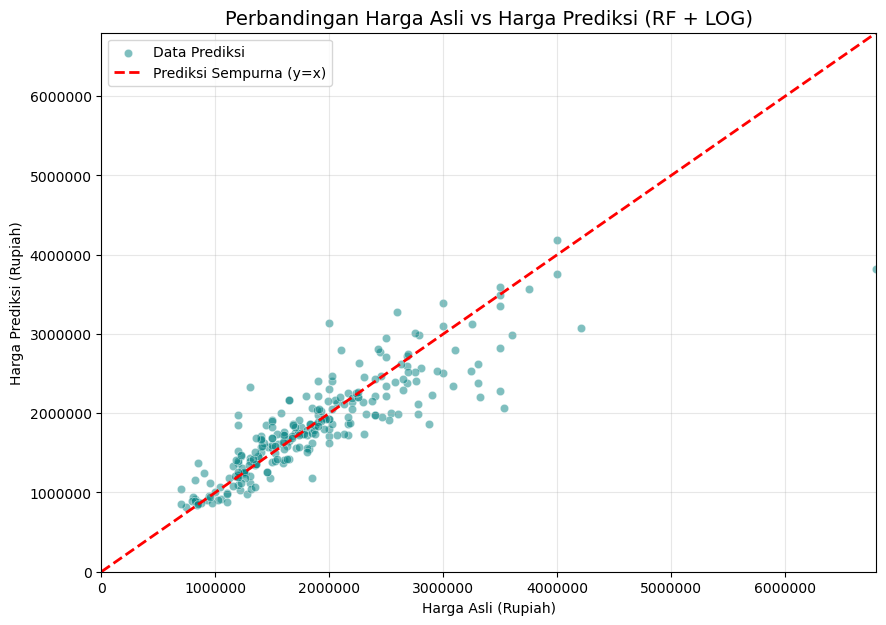

In [151]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.5, color='teal', label='Data Prediksi')

max_val = int(max(y_test_original.max(), y_pred_original.max()))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Prediksi Sempurna (y=x)')

plt.title('Perbandingan Harga Asli vs Harga Prediksi (RF + LOG)', fontsize=14)
plt.xlabel('Harga Asli (Rupiah)')
plt.ylabel('Harga Prediksi (Rupiah)')

plt.ticklabel_format(style='plain', axis='both')
plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

simpan X train, y train, X test, dan y train untuk ml flow

In [152]:
import numpy as np
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test) 
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

### Export csv yang berisi variabel untuk regresi

In [153]:
df.drop(columns=['location', 'room_name'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1233 entries, 7 to 2481
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   region                  1233 non-null   object 
 1   room_availability_bs    1233 non-null   float64
 2   price                   1233 non-null   float64
 3   rating                  1233 non-null   float64
 4   rating_count            1233 non-null   float64
 5   transaction_count       1233 non-null   float64
 6   tipe_kos                1233 non-null   object 
 7   room_area               1233 non-null   float64
 8   is_discount             1233 non-null   int64  
 9   is_electricity          1233 non-null   int64  
 10  is_kamar_mandi_dalam    1233 non-null   int64  
 11  is_kloset_duduk         1233 non-null   int64  
 12  fac_keamanan            1233 non-null   int64  
 13  fac_sirkulasi_udara     1233 non-null   int64  
 14  fac_parkir_motor        1233 non-null   int64

In [154]:
df.to_csv('../data/Data_Indekos_Jabodetabek_Mamikos_Regression.csv', index=False, float_format='%.2f')

## Model Top 5 Kos Recommendation

In [155]:
df_cleaned = pd.read_csv('../data/Data_Indekos_Jabodetabek_Mamikos_Cleaned.csv')

In [156]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

def get_top_5_recommendations(user_input_processed, df_cleaned):
    """
    Fungsi rekomendasi pintar: Menghitung fasilitas (biner) dan luas kamar 
    secara terpisah agar skor similarity-nya normal dan akurat.
    """
    fasilitas_user = [col for col in user_input_processed.columns if col != 'room_area' and user_input_processed[col].iloc[0] == 1.0]
    
    if len(fasilitas_user) == 0:
        fasilitas_user = [col for col in user_input_processed.columns if col != 'room_area']
        
    features_database = df_cleaned[fasilitas_user].copy().fillna(0)
    user_features = user_input_processed[fasilitas_user].copy().fillna(0)
    sim_fasilitas = cosine_similarity(user_features, features_database)[0]
    
    luas_user = user_input_processed['room_area'].iloc[0]
    luas_db = df_cleaned['room_area'].values
    sim_luas = 1 / (1 + np.abs(luas_db - luas_user))
    
    df_cleaned['similarity'] = (sim_fasilitas * 0.7) + (sim_luas * 0.3)
    
    recommendations = df_cleaned.sort_values(by='similarity', ascending=False).head(5)
    
    return recommendations[['room_name', 'price', 'room_area', 'similarity']]

In [157]:
features_blueprint = df_cleaned.select_dtypes(include=['number']).drop(columns=['price', 'similarity'], errors='ignore')

user_input_dummy = pd.DataFrame(0.0, index=[0], columns=features_blueprint.columns)

user_input_dummy['room_area'] = 13.2               
user_input_dummy['fac_ac'] = 1.0                  
user_input_dummy['fac_wifi'] = 1.0                
user_input_dummy['is_kamar_mandi_dalam'] = 1.0    

hasil_rekomendasi = get_top_5_recommendations(user_input_dummy, df_cleaned)

print("=== HASIL TESTING REKOMENDASI TOP 5 ===")
display(hasil_rekomendasi)

=== HASIL TESTING REKOMENDASI TOP 5 ===


,room_name,price,room_area,similarity
639,Kost Singgahsini Asia Baru 40A Tipe C Kebon Je...,1510000.0,13.30,0.972727
897,Kost Singgahsini Kivana Tipe D Matraman Jakart...,2613750.0,13.02,0.954237
697,Kost Singgahsini Casa Tebet Mas Indah Tipe A T...,3825000.0,12.96,0.941935
709,Kost Singgahsini Clean Room SPR Tipe A Taman S...,2025000.0,12.96,0.941935
603,Kost Singgahsini Alaya Pejompongan Tipe A Tana...,1995000.0,12.96,0.941935


## Import Model ke file .pkl

In [158]:
import pickle

with open('../models/model_kos.pkl', 'wb') as file:
    pickle.dump(rf_log_model, file)

model_columns = list(X_train.columns) if 'X_train' in locals() else list(features_blueprint.columns)

with open('../models/model_columns.pkl', 'wb') as file:
    pickle.dump(model_columns, file)